In [1]:
!hostname

gnode011.cluster


In [2]:
!nvidia-smi

No devices were found


In [3]:
import itertools as it
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import torch.fft
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sdeint
from toolbox import (
    make_loss,
    StatLoss,
    SINN,
    FPU
)
import time

In [4]:
from scipy.integrate import quad
from scipy import stats
import multiprocessing
from multiprocessing import Pool, cpu_count
import os
import psutil

In [5]:
import torch

In [6]:
torch.cuda.is_available()

False

In [7]:
device = torch.device('cuda')

In [8]:
print(torch.__version__)
print(torch.version.cuda)

2.0.1+cu118
11.8


In [9]:
from scipy.signal import argrelextrema

# Parameters
A = 0.02                   # Driving strength

def f(x):
    return -0.5 * x**2 + 0.25 * x**4 - A * x

# Parameters
x_range = np.linspace(-2, 2, 1000)  # High resolution to capture small changes

# Calculate function values
y = f(x_range)

# Find local minima and maxima
maxima_indices = argrelextrema(y, np.greater)[0]
minima_indices = argrelextrema(y, np.less)[0]
print(maxima_indices)
print(minima_indices)

[495]
[252 752]


In [10]:
minima_indices[0]

252

A: ( -0.9909909909909911 , -0.23009974748140966 )
B: ( -0.018018018018018056 , 0.00019806222295051527 )
C: ( 1.011011011011011 , -0.27009763918080865 )


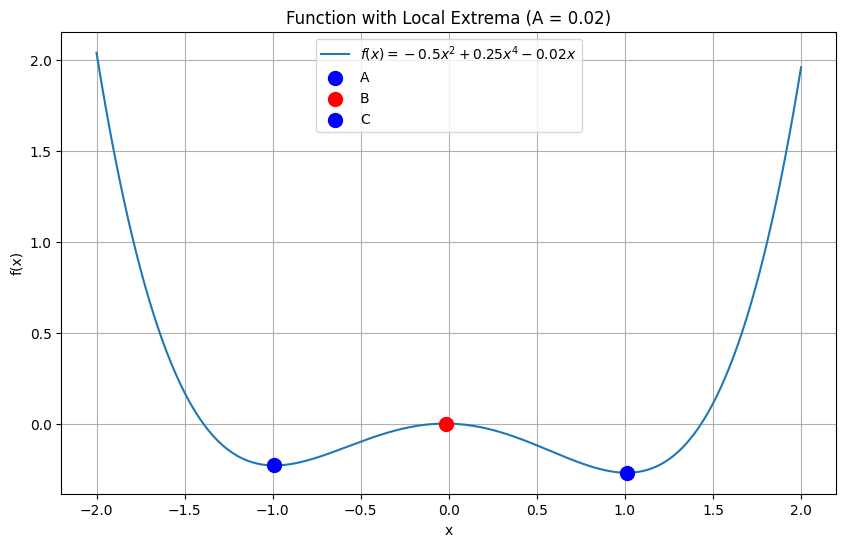

In [11]:
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_range, y, label=r'$f(x) = -0.5x^2 + 0.25x^4 - 0.02x$')

# Mark extrema
plt.scatter(x_range[minima_indices[0]], y[minima_indices[0]], 
            color='blue', s=100, label='A', zorder=5)
print('A: (',x_range[minima_indices[0]],',',y[minima_indices[0]],')')
plt.scatter(x_range[maxima_indices[0]], y[maxima_indices[0]], 
            color='red', s=100, label='B', zorder=5)
print('B: (',x_range[maxima_indices[0]],',',y[maxima_indices[0]],')')
plt.scatter(x_range[minima_indices[1]], y[minima_indices[1]], 
            color='blue', s=100, label='C', zorder=5)
print('C: (',x_range[minima_indices[1]],',',y[minima_indices[1]],')')
plt.title('Function with Local Extrema (A = 0.02)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()

$<\tau>=\dfrac1D \dfrac{2\pi k_B T}{m\omega_a \omega_b}e^{\beta E^{+}_b}$

$D=\dfrac{k_B T}{\gamma}$ 

$\omega_a = \sqrt{\dfrac{U''(x_a)}{m}}$, $\omega_b = \sqrt{\dfrac{U''(x_b)}{m}}$ 

$E^{+}_b=U_B-U_A$

thermal energy: $k_B T << E^{+}_b$

$\beta = \dfrac{1}{k_B T}$

$<\tau>= \dfrac{2\pi \gamma}{\sqrt{U''(x_a)} \sqrt{U''(x_b)} }e^{\beta E^{+}_b}$


In [12]:
E_b = y[maxima_indices[0]] - y[minima_indices[0]]
E_b 

0.23029780970436017

$E^{+}_b=0.23029780970436017$

In [13]:
thermal_energy = E_b/5
thermal_energy

0.04605956194087203

$k_B T = 0.04605956194087203$

In [14]:
print(y[maxima_indices[0]] - y[minima_indices[1]])

0.27029570140375914


$E^{-}_b=0.27029570140375914$

So we have $k_B T<<E^{+}_b<E^{-}_b$

In [15]:
def d2V_dx2(x):
    return -1 + 3 * x**2

In [16]:
d2V_dx2_a = d2V_dx2(x_range[minima_indices[0]])
d2V_dx2_a

1.94618943267592

In [17]:
d2V_dx2_b = d2V_dx2(x_range[maxima_indices[0]])
d2V_dx2_b

-0.9990260530801072

In [18]:
# Parameters
D = 1/20                   # Fluctuation strength
gamma = thermal_energy/D                # Damping coefficient
beta = 1.0/thermal_energy

In [19]:
gamma

0.9211912388174406

In [20]:
beta

21.711018469600912

In [21]:
tau = 2*np.pi*gamma/np.sqrt(abs(d2V_dx2_a))/np.sqrt(abs(d2V_dx2_b))*np.exp(beta*E_b)
tau

616.0573092061182

In [22]:
# Parameters
T = 5 * tau                # Period 
Omega = 2 * np.pi / T      # Frequency of the oscillation

dt= 0.01                   # Step-size of the SDE solver 
delta_t= T/40              # Step-size of the temporally coarse-grained path
sec_length = 400           # Length of the input sequence
batch = 1120               # Batch size 

In [23]:
T

3080.286546030591

In [24]:
delta_t

77.00716365076478

In [25]:
# Potential function and its derivative
def V(x, t):
    return -0.5 * x**2 + 0.25 * x**4 - A * x * np.sin(Omega * t)

def dV_dx(x, t):
    return -x + x**3 - A * np.sin(Omega * t)

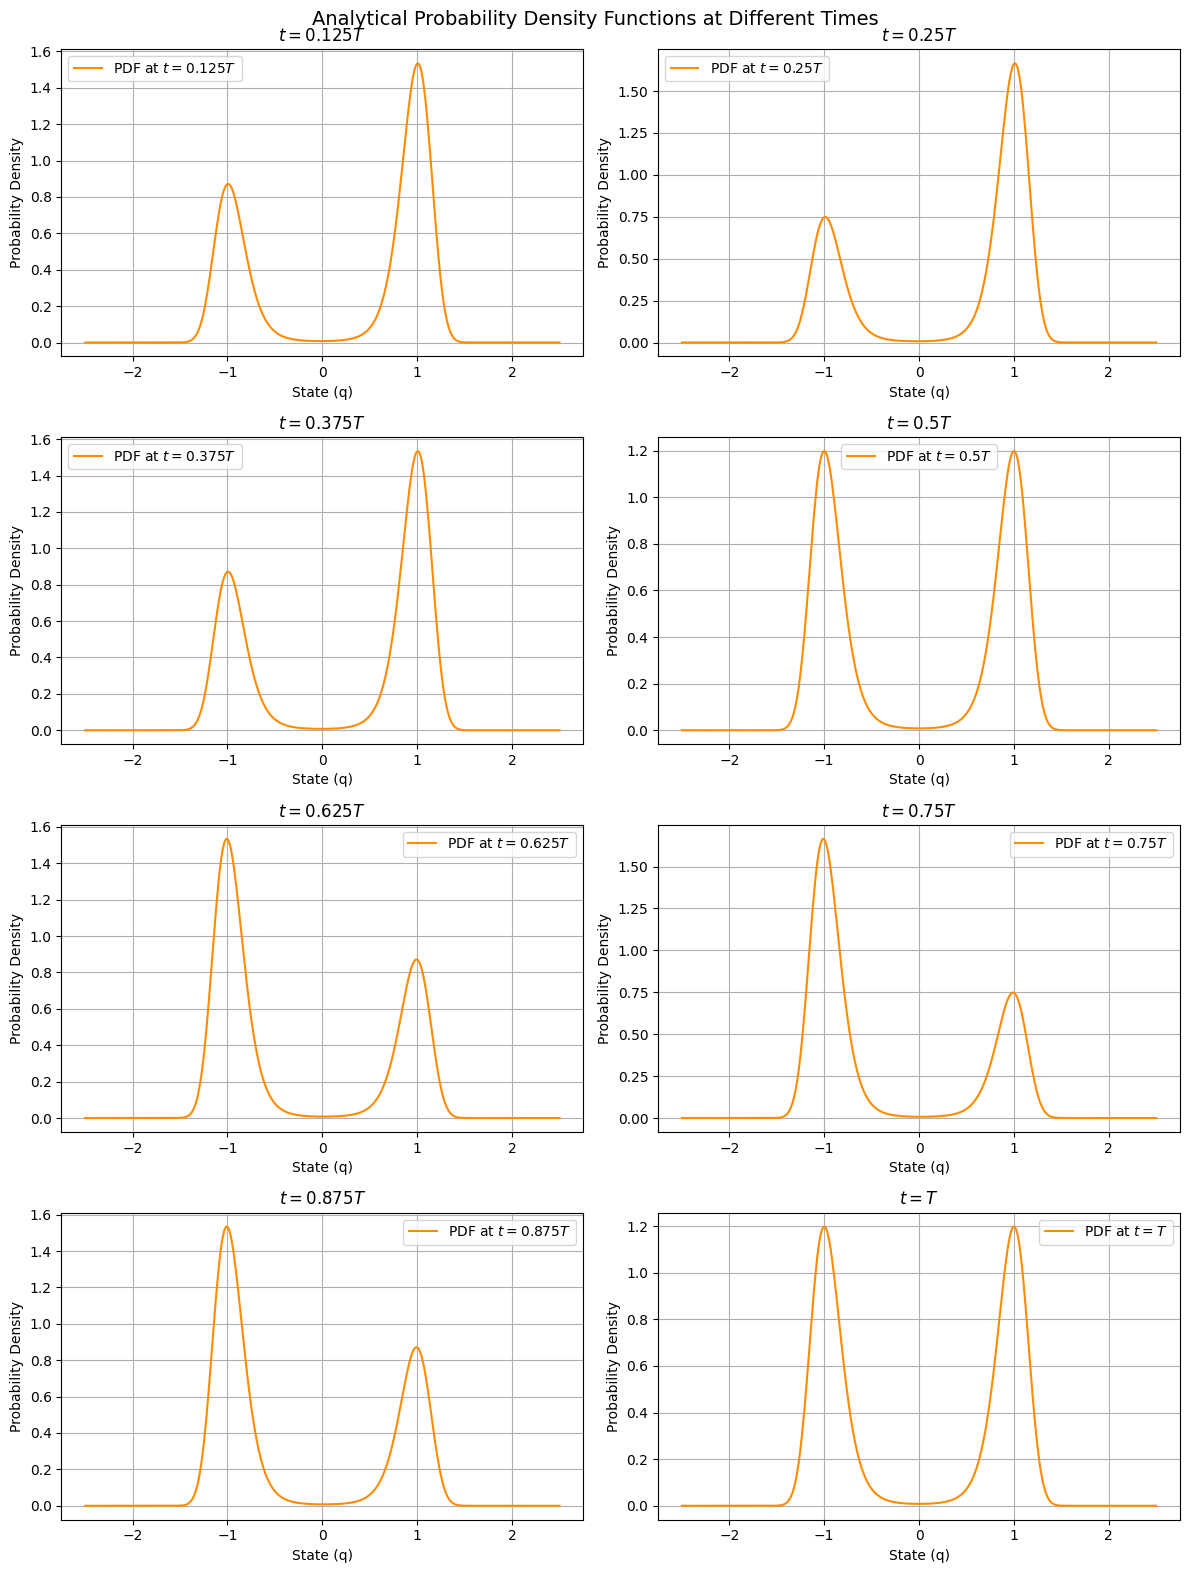

In [26]:
# Define x-range for normalization
x = np.linspace(-2.5, 2.5, sec_length)

# Compute the unnormalized PDF over the x-range
def analytical_pdf(x, t):
    potential = V(x, t)
    unnormalized = np.exp(-potential / D)
    Z = np.trapz(unnormalized, x)
    return unnormalized/Z

# Time points to evaluate
# 8 plots
time_points = [0.125 * T, 0.25 * T, 0.375 * T, 0.5 * T,
               0.625 * T, 0.75 * T, 0.875 * T, 1.0 * T]

titles = [r'$t = 0.125T$', r'$t = 0.25T$', r'$t = 0.375T$', r'$t = 0.5T$', 
          r'$t = 0.625T$', r'$t = 0.75T$', r'$t = 0.875T$', r'$t = T$']

# Create subplots
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
fig.suptitle('Analytical Probability Density Functions at Different Times', fontsize=14)
axes = axes.flatten()  # Flatten for easy iteration

for i, (t, title) in enumerate(zip(time_points, titles)):
    pdf = analytical_pdf(x, t)
    axes[i].plot(x, pdf, color='darkorange', label=f'PDF at {title}')
    axes[i].set_xlabel("State (q)")
    axes[i].set_ylabel("Probability Density")
    axes[i].set_title(title)
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [27]:
### SDE solver (EM scheme), 
Time = 5*delta_t*sec_length
print(Time)
length=int(Time/dt)+1
t = np.linspace(0, Time, length) # define time axis
gap=int(delta_t/dt)
t_store=t[0:-1:gap]
q_store = np.zeros([t_store.size+1,batch])
minibatch = 20

154014.32730152956


In [28]:
def solve_sde(batch_idx):
    np.random.seed((batch_idx+1)*100)
    name = multiprocessing.current_process().name        
    print(f'>>>>>>>===============================================\n{name} starting. \nparent process:{os.getppid()}------process id:{os.getpid()}\n===============================================>>>>>>>\n')    
    
    # Set initial condition based on probabilities
    q = np.zeros((2, minibatch))
    q[0, :] = 1
    
    local_q_store = np.zeros([t_store.size + 1, minibatch])    

    j = 1
    for i in range(1, length):
        q[1,:] = q[0,:] - dV_dx(q[0,:], i * dt) * dt + np.random.randn(1, minibatch) * np.sqrt(2 * dt * D)
        
        if i % gap == 0:
            local_q_store[j, : ] = q[1, :]
            j += 1
        q[0, :] = q[1, :] 
    
    print(f"Batch {batch_idx} completed. \n")
    return batch_idx, local_q_store

In [29]:
if __name__ == '__main__':
    start = time.time()
    test_batch = int(batch / minibatch)
    num_cores = min(cpu_count(), test_batch)
    with Pool(num_cores) as pool:
        results = pool.map(solve_sde, range(test_batch))
    pool.close()
    pool.join()
    
    end = time.time()
    
    print(f'total runtime: {end-start}')

>>>>>>>===============================================
ForkPoolWorker-1 starting. 
parent process:482647------process id:482839
===============================================>>>>>>>
>>>>>>>===============================================
ForkPoolWorker-5 starting. 
parent process:482647------process id:482843
===============================================>>>>>>>
>>>>>>>===============================================
ForkPoolWorker-2 starting. 
parent process:482647------process id:482840
===============================================>>>>>>>
>>>>>>>===============================================
ForkPoolWorker-4 starting. 
parent process:482647------process id:482842
===============================================>>>>>>>
>>>>>>>===============================================
ForkPoolWorker-3 starting. 
parent process:482647------process id:482841
===============================================>>>>>>>
>>>>>>>===============================================
ForkPoolWorker-7 starting. 
pa

>>>>>>>===============================================
ForkPoolWorker-46 starting. 
parent process:482647------process id:482884
===============================================>>>>>>>

>>>>>>>===============================================
ForkPoolWorker-51 starting. 
parent process:482647------process id:482889
===============================================>>>>>>>
>>>>>>>===============================================
ForkPoolWorker-48 starting. 
parent process:482647------process id:482886
===============================================>>>>>>>
>>>>>>>===============================================
ForkPoolWorker-50 starting. 
parent process:482647------process id:482888
===============================================>>>>>>>


>>>>>>>===============================================
ForkPoolWorker-52 starting. 
parent process:482647------process id:482890
===============================================>>>>>>>
>>>>>>>===============================================
ForkPoolWorker-53 star

In [30]:
for i, local_q_store in results:
        q_store[:, i*minibatch:(i+1)*minibatch] = local_q_store


Toss=int(t_store.size/2)
q_store=q_store[Toss:-1,:] 

Text(0.5, 1.0, 'Solution of the Transtion dynamics')

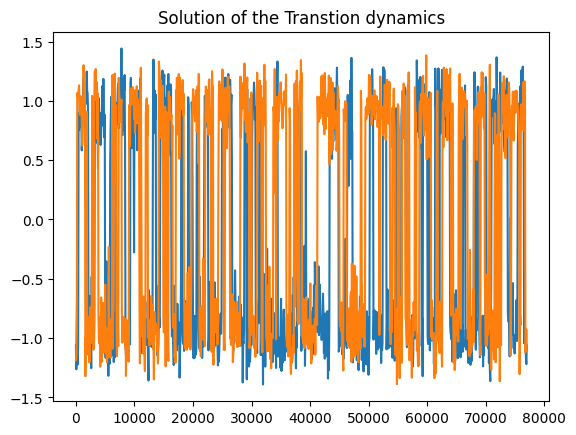

In [31]:
plt.figure(1)
for i in range(2):
    plt.plot(t_store[Toss:]-t_store[Toss],q_store[:,i])
# plt.legend()
plt.title("Solution of the Transtion dynamics")

In [32]:
#####################  Construct the sample traj for SINN learning 
ini=np.random.randn(sec_length,batch)
Traj=q_store[-sec_length:,:]
Time_seq=np.arange(len(Traj[:,1]))*delta_t
print(ini.shape, Traj.shape)

(400, 1120) (400, 1120)


In [33]:
Traj = Traj.astype(np.float32) 

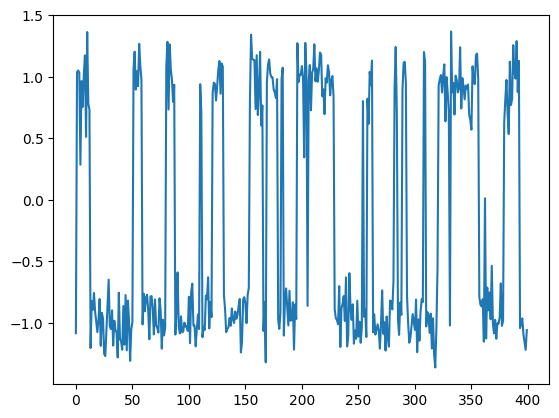

In [34]:
plt.plot(Traj[:,0])

In [35]:
start = 5
step = 40
indices = torch.arange(start, 400, step)

In [36]:
Traj_1 = Traj[indices,:]

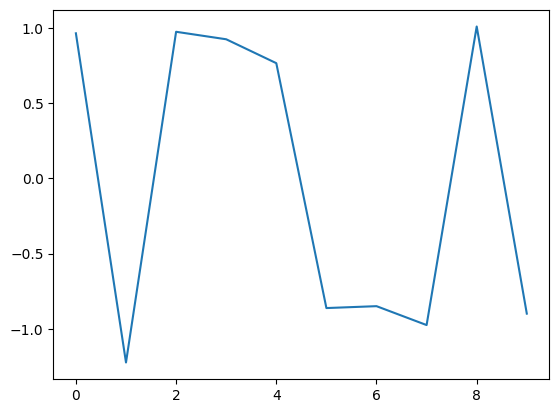

In [37]:
plt.plot(Traj_1[:,0])

In [38]:
# Traj_1 = torch.from_numpy(Traj_1.reshape(10, batch, 1)).to(device)
Traj_1 = torch.from_numpy(Traj_1.reshape(10, batch, 1))

In [39]:
# Defining Loss functions
N = 400
loss_pdf_empirical1 = make_loss('pdf', Traj_1, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

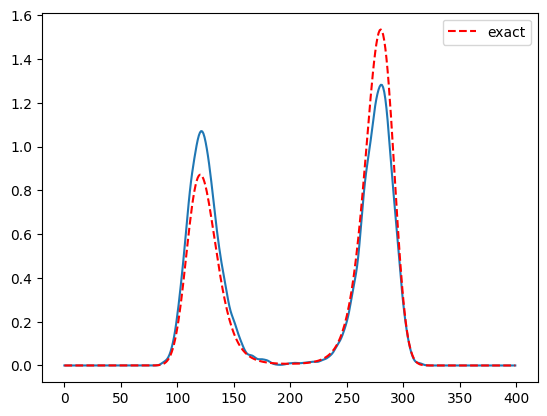

In [40]:
plt.plot(loss_pdf_empirical1._target.cpu())
pdf = analytical_pdf(x, 0.125*T)
plt.plot(pdf,'r--', label = 'exact')
plt.legend()

In [41]:
start = 4
step = 40
indices = torch.arange(start, 400, step)
Traj_1_1 = Traj[indices,:]

In [42]:
Traj_1_1 = torch.from_numpy(Traj_1_1.reshape(10, batch, 1))

In [43]:
loss_pdf_empirical1_1 = make_loss('pdf', Traj_1_1, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

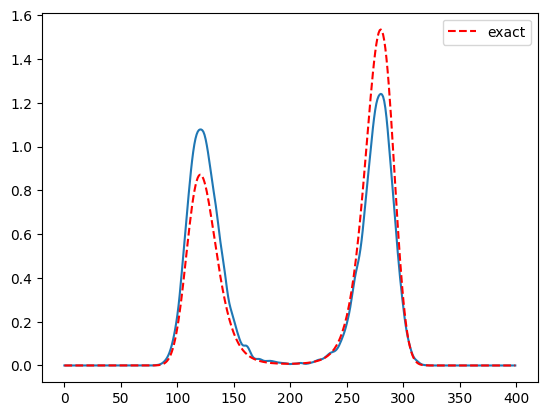

In [44]:
plt.plot(loss_pdf_empirical1_1._target.cpu())
pdf = analytical_pdf(x, 0.125*T)
plt.plot(pdf,'r--', label = 'exact')
plt.legend()

In [45]:
start = 6
step = 40
indices = torch.arange(start, 400, step)
Traj_1_2 = Traj[indices,:]

In [46]:
Traj_1_2 = torch.from_numpy(Traj_1_2.reshape(10, batch, 1))

In [47]:
loss_pdf_empirical1_2 = make_loss('pdf', Traj_1_2, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

Text(0.5, 1.0, 'bw=0.2')

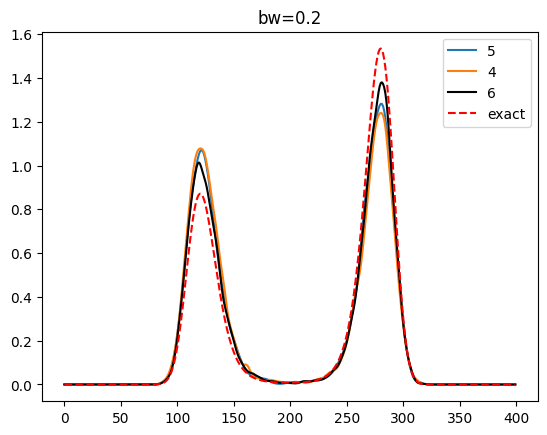

In [48]:
plt.plot(loss_pdf_empirical1._target.cpu(), label = '5')
plt.plot(loss_pdf_empirical1_1._target.cpu(), label = '4')
plt.plot(loss_pdf_empirical1_2._target.cpu(), 'k',label = '6')
pdf = analytical_pdf(x, 0.125*T)
plt.plot(pdf,'r--', label = 'exact')
plt.legend()
plt.title('bw=0.2')

In [49]:
loss_pdf_empirical1 = make_loss('pdf', Traj_1, lower=-2.5, upper=2.5, n=N, bw=0.15, device=device)
loss_pdf_empirical1_1 = make_loss('pdf', Traj_1_1, lower=-2.5, upper=2.5, n=N, bw=0.15, device=device)
loss_pdf_empirical1_2 = make_loss('pdf', Traj_1_2, lower=-2.5, upper=2.5, n=N, bw=0.15, device=device)

Text(0.5, 1.0, 'bw=0.15')

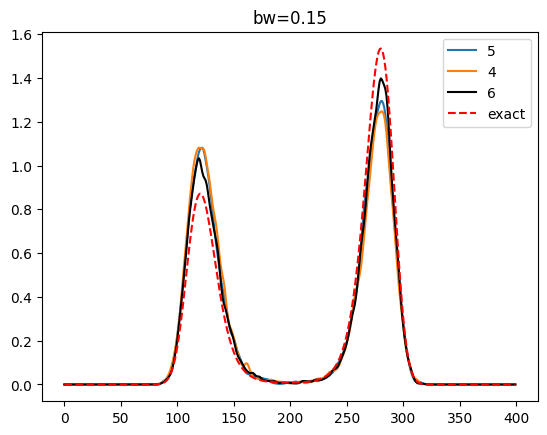

In [50]:
plt.plot(loss_pdf_empirical1._target.cpu(), label = '5')
plt.plot(loss_pdf_empirical1_1._target.cpu(), label = '4')
plt.plot(loss_pdf_empirical1_2._target.cpu(), 'k',label = '6')
pdf = analytical_pdf(x, 0.125*T)
plt.plot(pdf,'r--', label = 'exact')
plt.legend()
plt.title('bw=0.15')

In [51]:
start = 10
step = 40
indices = torch.arange(start, 400, step)

In [52]:
Traj_2 = Traj[indices,:]

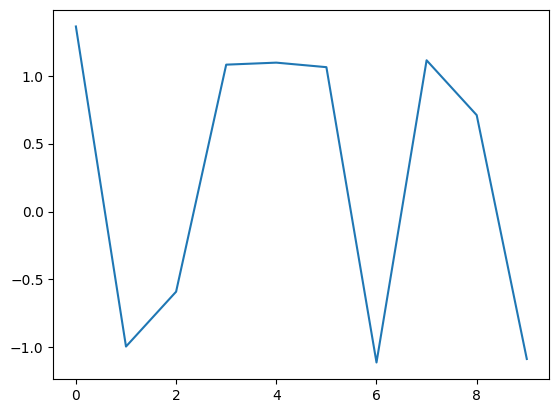

In [53]:
plt.plot(Traj_2[:,0])

In [54]:
Traj_2 = torch.from_numpy(Traj_2.reshape(10, batch, 1))

In [55]:
# Defining Loss functions
N = 400
loss_pdf_empirical2 = make_loss('pdf', Traj_2, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

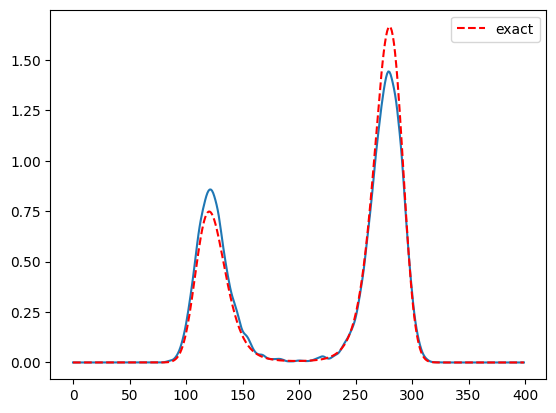

In [56]:
plt.plot(loss_pdf_empirical2._target.cpu())
pdf = analytical_pdf(x, 0.25*T)
plt.plot(pdf,'r--', label = 'exact')
plt.legend()

In [57]:
start = 15
step = 40
indices = torch.arange(start, 400, step)
Traj_3 = Traj[indices,:]

In [58]:
Traj_3 = torch.from_numpy(Traj_3.reshape(10, batch, 1))

In [59]:
#bw = 0.1 and 0.2
loss_pdf_empirical3 = make_loss('pdf', Traj_3, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

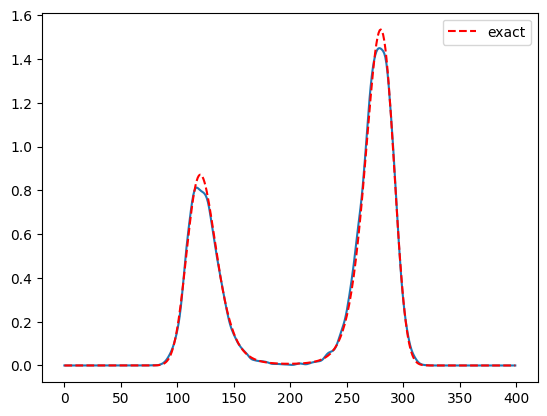

In [60]:
plt.plot(loss_pdf_empirical3._target.cpu())
pdf = analytical_pdf(x, 0.375*T)
plt.plot(pdf,'r--', label = 'exact')
plt.legend()

In [61]:
start = 20
step = 40
indices = torch.arange(start, 400, step)
Traj_4 = Traj[indices,:]

In [62]:
Traj_4 = torch.from_numpy(Traj_4.reshape(10, batch, 1))

In [63]:
loss_pdf_empirical4 = make_loss('pdf', Traj_4, lower=-2.5, upper=2.5, n=N, bw=0.15, device=device)

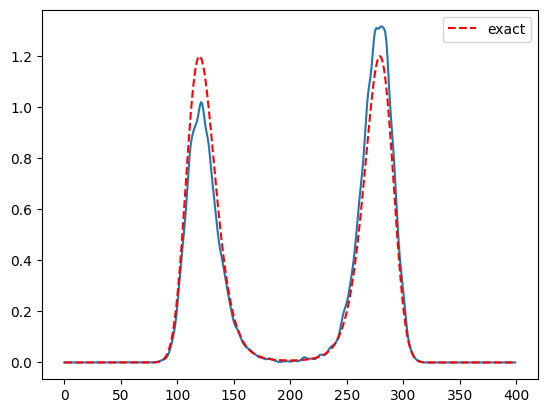

In [64]:
plt.plot(loss_pdf_empirical4._target.cpu())
pdf = analytical_pdf(x, 0.5*T)
plt.plot(pdf,'r--', label = 'exact')
plt.legend()

In [65]:
start = 19
step = 40
indices = torch.arange(start, 400, step)
Traj_4_1 = Traj[indices,:]

In [66]:
Traj_4_1 = torch.from_numpy(Traj_4_1.reshape(10, batch, 1))

In [67]:
loss_pdf_empirical4_1 = make_loss('pdf', Traj_4_1, lower=-2.5, upper=2.5, n=N, bw=0.15, device=device)

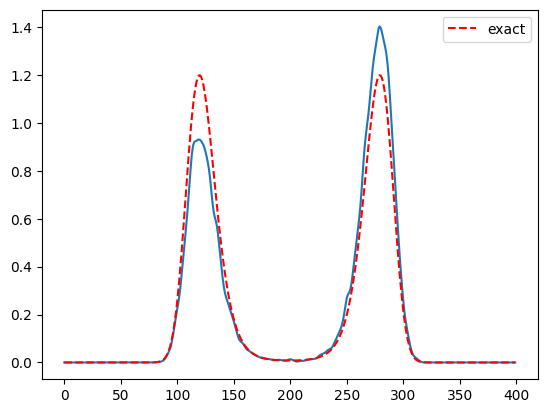

In [68]:
plt.plot(loss_pdf_empirical4_1._target.cpu())
pdf = analytical_pdf(x, 0.5*T)
plt.plot(pdf,'r--', label = 'exact')
plt.legend()

In [69]:
start = 21
step = 40
indices = torch.arange(start, 400, step)
Traj_4_2 = Traj[indices,:]

In [70]:
Traj_4_2 = torch.from_numpy(Traj_4_2.reshape(10, batch, 1))

In [71]:
loss_pdf_empirical4_2 = make_loss('pdf', Traj_4_2, lower=-2.5, upper=2.5, n=N, bw=0.15, device=device)

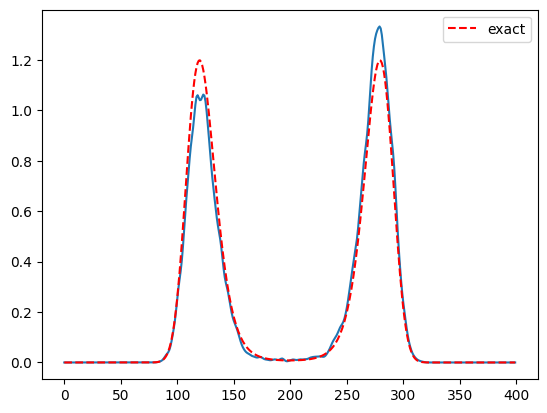

In [72]:
plt.plot(loss_pdf_empirical4_2._target.cpu())
pdf = analytical_pdf(x, 0.5*T)
plt.plot(pdf,'r--', label = 'exact')
plt.legend()

Text(0.5, 1.0, 'bw=0.15')

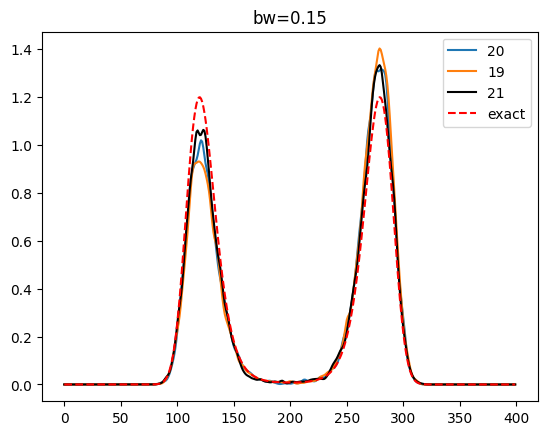

In [73]:
plt.plot(loss_pdf_empirical4._target.cpu(), label = '20')
plt.plot(loss_pdf_empirical4_1._target.cpu(), label = '19')
plt.plot(loss_pdf_empirical4_2._target.cpu(),'k', label = '21')
pdf = analytical_pdf(x, 0.5*T)
plt.plot(pdf,'r--', label = 'exact')
plt.legend()
plt.title('bw=0.15')

In [74]:
loss_pdf_empirical4 = make_loss('pdf', Traj_4, lower=-2.5, upper=2.5, n=N, bw=0.1, device=device)
loss_pdf_empirical4_1 = make_loss('pdf', Traj_4_1, lower=-2.5, upper=2.5, n=N, bw=0.1, device=device)
loss_pdf_empirical4_2 = make_loss('pdf', Traj_4_2, lower=-2.5, upper=2.5, n=N, bw=0.1, device=device)

Text(0.5, 1.0, 'bw=0.1')

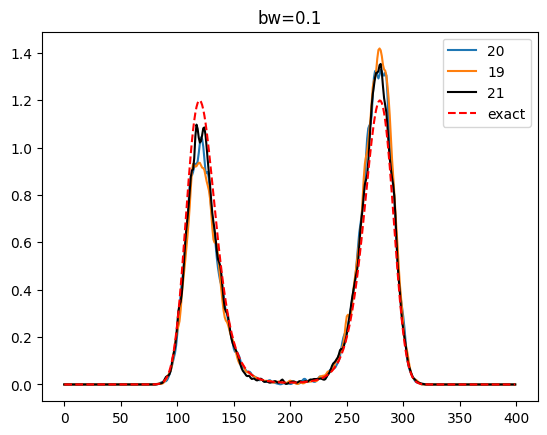

In [75]:
plt.plot(loss_pdf_empirical4._target.cpu(), label = '20')
plt.plot(loss_pdf_empirical4_1._target.cpu(), label = '19')
plt.plot(loss_pdf_empirical4_2._target.cpu(),'k', label = '21')
pdf = analytical_pdf(x, 0.5*T)
plt.plot(pdf,'r--', label = 'exact')
plt.legend()
plt.title('bw=0.1')

In [76]:
loss_pdf_empirical4 = make_loss('pdf', Traj_4, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)
loss_pdf_empirical4_1 = make_loss('pdf', Traj_4_1, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)
loss_pdf_empirical4_2 = make_loss('pdf', Traj_4_2, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

Text(0.5, 1.0, 'bw=0.2')

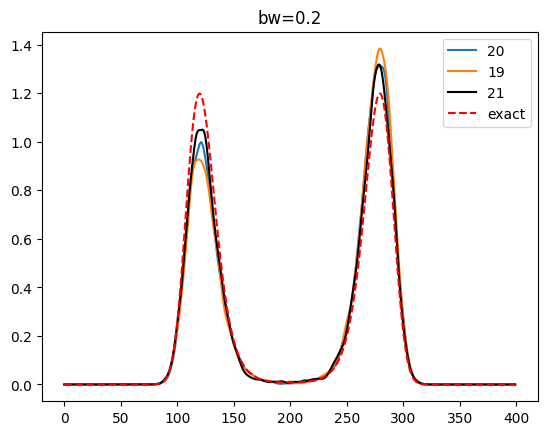

In [77]:
plt.plot(loss_pdf_empirical4._target.cpu(), label = '20')
plt.plot(loss_pdf_empirical4_1._target.cpu(), label = '19')
plt.plot(loss_pdf_empirical4_2._target.cpu(),'k', label = '21')
pdf = analytical_pdf(x, 0.5*T)
plt.plot(pdf,'r--', label = 'exact')
plt.legend()
plt.title('bw=0.2')

In [78]:
start = 25
step = 40
indices = torch.arange(start, 400, step)
Traj_5 = Traj[indices,:]

In [79]:
Traj_5 = torch.from_numpy(Traj_5.reshape(10, batch, 1))

In [80]:
loss_pdf_empirical5 = make_loss('pdf', Traj_5, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

Text(0.5, 1.0, 'bw=0.2')

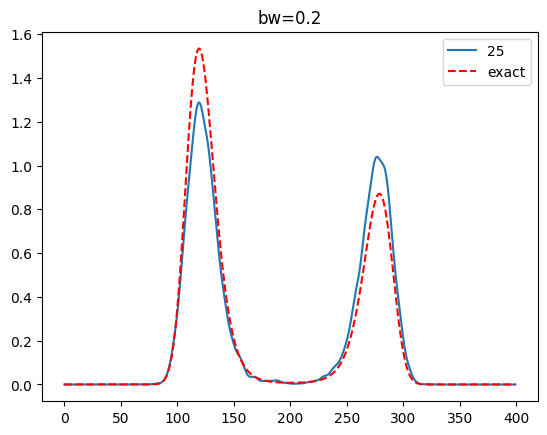

In [81]:
plt.plot(loss_pdf_empirical5._target.cpu(), label = '25')
pdf = analytical_pdf(x, 0.625*T)
plt.plot(pdf,'r--', label = 'exact')
plt.legend()
plt.title('bw=0.2')

In [82]:
start = 24
step = 40
indices = torch.arange(start, 400, step)
Traj_5_1 = Traj[indices,:]

In [83]:
Traj_5_1 = torch.from_numpy(Traj_5_1.reshape(10, batch, 1))

In [84]:
loss_pdf_empirical5_1 = make_loss('pdf', Traj_5_1, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

Text(0.5, 1.0, 'bw=0.2')

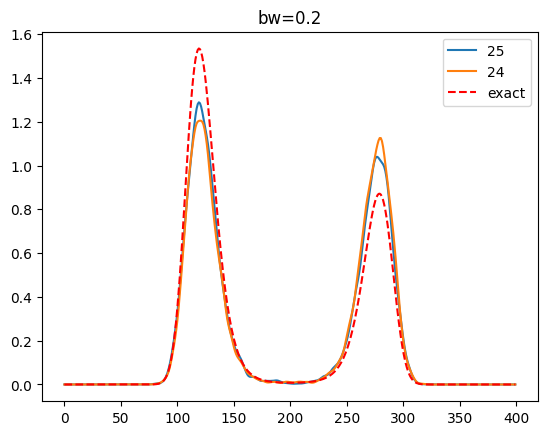

In [85]:
plt.plot(loss_pdf_empirical5._target.cpu(), label = '25')
plt.plot(loss_pdf_empirical5_1._target.cpu(), label = '24')
pdf = analytical_pdf(x, 0.625*T)
plt.plot(pdf,'r--', label = 'exact')
plt.legend()
plt.title('bw=0.2')

In [86]:
start = 26
step = 40
indices = torch.arange(start, 400, step)
Traj_5_2 = Traj[indices,:]

In [87]:
Traj_5_2 = torch.from_numpy(Traj_5_2.reshape(10, batch, 1))

In [88]:
loss_pdf_empirical5_2 = make_loss('pdf', Traj_5_2, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

Text(0.5, 1.0, 'bw=0.2')

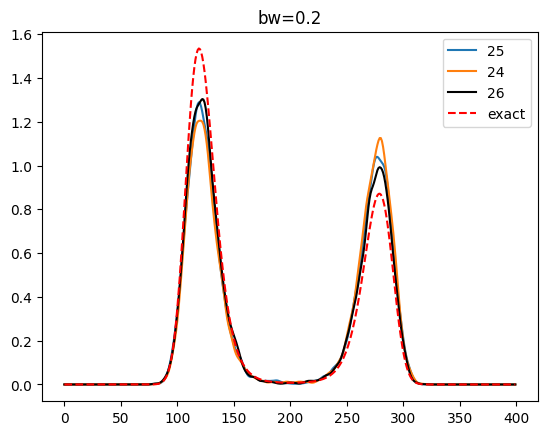

In [89]:
plt.plot(loss_pdf_empirical5._target.cpu(), label = '25')
plt.plot(loss_pdf_empirical5_1._target.cpu(), label = '24')
plt.plot(loss_pdf_empirical5_2._target.cpu(),'k', label = '26')
pdf = analytical_pdf(x, 0.625*T)
plt.plot(pdf,'r--', label = 'exact')
plt.legend()
plt.title('bw=0.2')

In [90]:
start = 30
step = 40
indices = torch.arange(start, 400, step)
Traj_6 = Traj[indices,:]

In [91]:
Traj_6 = torch.from_numpy(Traj_6.reshape(10, batch, 1))

In [92]:
loss_pdf_empirical6 = make_loss('pdf', Traj_6, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

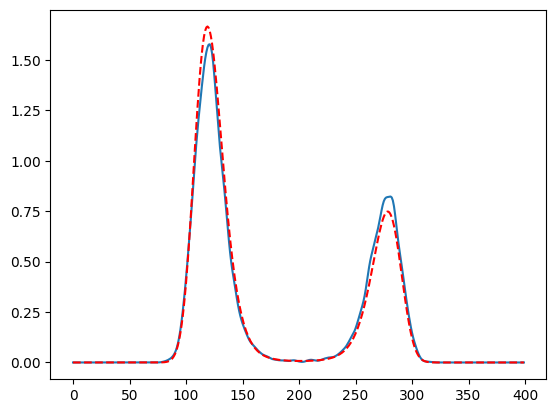

In [93]:
plt.plot(loss_pdf_empirical6._target.cpu())
pdf = analytical_pdf(x, 0.75*T)
plt.plot(pdf,'r--')

In [94]:
start = 35
step = 40
indices = torch.arange(start, 400, step)
Traj_7 = Traj[indices,:]

In [95]:
Traj_7 = torch.from_numpy(Traj_7.reshape(10, batch, 1))

In [96]:
loss_pdf_empirical7 = make_loss('pdf', Traj_7, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

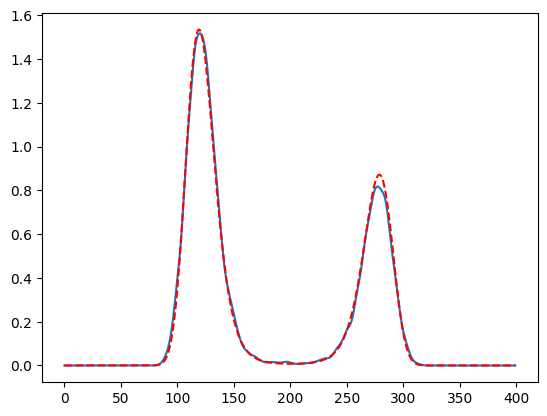

In [97]:
plt.plot(loss_pdf_empirical7._target.cpu())
pdf = analytical_pdf(x, 0.875*T)
plt.plot(pdf,'r--')

In [98]:
start = 0
step = 40
indices = torch.arange(start, 400, step)
Traj_8 = Traj[indices,:]

In [99]:
Traj_8 = torch.from_numpy(Traj_8.reshape(10, batch, 1))

In [100]:
loss_pdf_empirical8 = make_loss('pdf', Traj_8, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

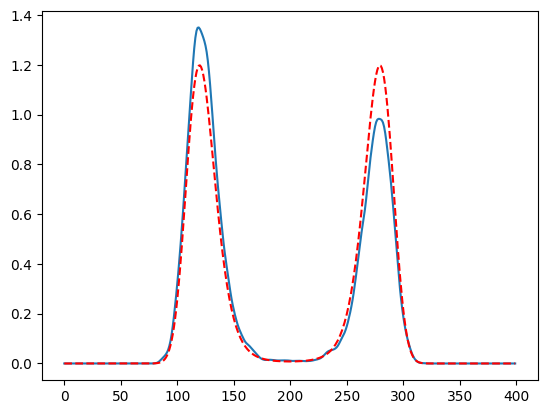

In [101]:
plt.plot(loss_pdf_empirical8._target.cpu())
pdf = analytical_pdf(x, T)
plt.plot(pdf,'r--')

In [102]:
start = 39
step = 40
indices = torch.arange(start, 400, step)
Traj_8_1 = Traj[indices,:]

In [103]:
Traj_8_1 = torch.from_numpy(Traj_8_1.reshape(10, batch, 1))

In [104]:
loss_pdf_empirical8_1 = make_loss('pdf', Traj_8_1, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

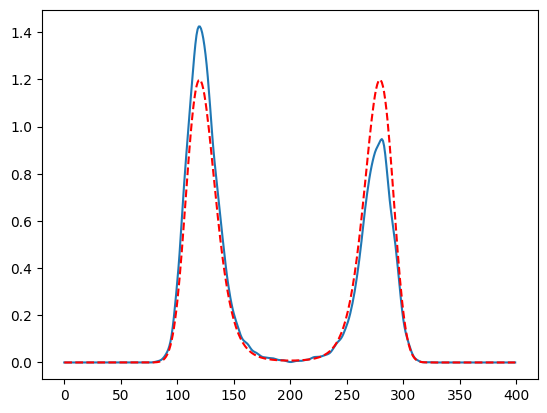

In [105]:
plt.plot(loss_pdf_empirical8_1._target.cpu())
pdf = analytical_pdf(x, T)
plt.plot(pdf,'r--')

In [106]:
start = 1
step = 40
indices = torch.arange(start, 400, step)
Traj_8_2 = Traj[indices,:]

In [107]:
Traj_8_2 = torch.from_numpy(Traj_8_2.reshape(10, batch, 1))

In [108]:
loss_pdf_empirical8_2 = make_loss('pdf', Traj_8_2, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

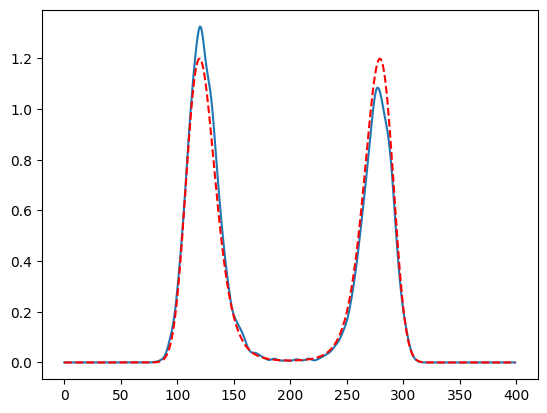

In [109]:
plt.plot(loss_pdf_empirical8_2._target.cpu())
pdf = analytical_pdf(x, T)
plt.plot(pdf,'r--')

Text(0.5, 1.0, 'bw=0.2')

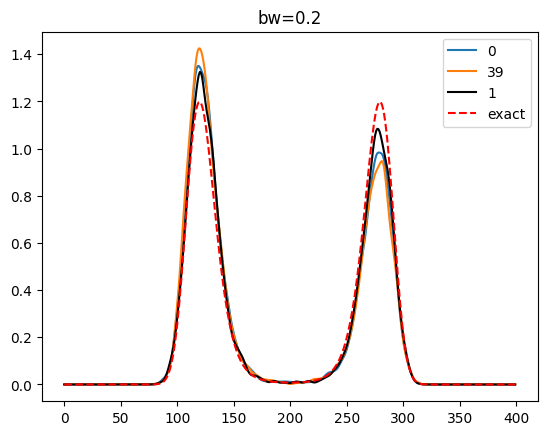

In [110]:
plt.plot(loss_pdf_empirical8._target.cpu(), label = '0')
plt.plot(loss_pdf_empirical8_1._target.cpu(), label = '39')
plt.plot(loss_pdf_empirical8_2._target.cpu(), 'k',label = '1')
pdf = analytical_pdf(x, T)
plt.plot(pdf,'r--', label = 'exact')
plt.legend()
plt.title('bw=0.2')